<a href="https://colab.research.google.com/github/caraleog0560/FIME/blob/main/ACTIVIDADES/EMC_AIyRN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parte 1: Carga y Limpieza (Pandas y NumPy)**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lee el archivo CSV desde la URL proporcionada y guárdalo en un DataFrame.
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

# Imprime las primeras 5 filas y usa un comando para mostrar los tipos de datos de cada columna.
print("\n 1. Primeras 5 filas del dataset")
display(df.head())

print("\n 2. Tipos de datos de cada columna")
print(df.dtypes)

# Identifica si hay valores nulos en la columna horsepower (caballos de fuerza).

nulos_antes = df['horsepower'].isnull().sum()
print(f"\nValores nulos en 'horsepower' antes de limpiar: {nulos_antes}")

# Reemplaza esos valores nulos con la mediana de esa misma columna usando NumPy y Pandas.
mediana_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(mediana_hp)

nulos_despues = df['horsepower'].isnull().sum()
print(f"Valores nulos en 'horsepower' después de limpiar: {nulos_despues}")

# Crea una nueva columna llamada relacion_peso_potencia que sea el resultado de dividir la columna weight (peso) entre horsepower.

df['relacion_peso_potencia'] = df['weight'] / df['horsepower']

print("\n 3. Comprobación de la nueva columna")
display(df[['name', 'weight', 'horsepower', 'relacion_peso_potencia']].head())


 1. Primeras 5 filas del dataset


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



 2. Tipos de datos de cada columna
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

Valores nulos en 'horsepower' antes de limpiar: 6
Valores nulos en 'horsepower' después de limpiar: 0

 3. Comprobación de la nueva columna


,name,weight,horsepower,relacion_peso_potencia
0,chevrolet chevelle malibu,3504,130.0,26.953846
1,buick skylark 320,3693,165.0,22.381818
2,plymouth satellite,3436,150.0,22.906667
3,amc rebel sst,3433,150.0,22.886667
4,ford torino,3449,140.0,24.635714


# **Parte 2: Visualización de Datos (Matplotlib)**





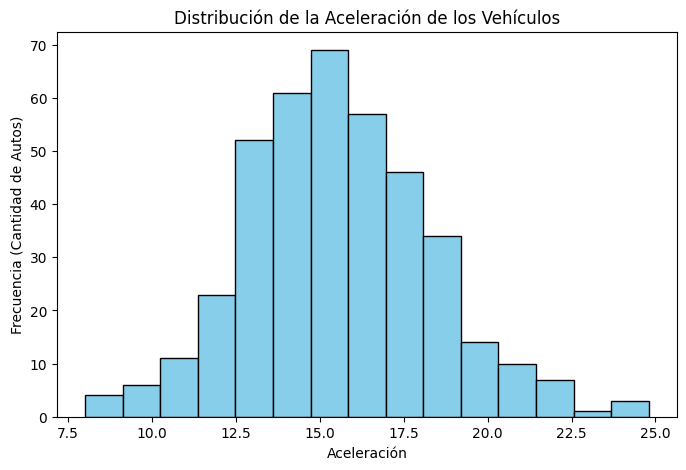

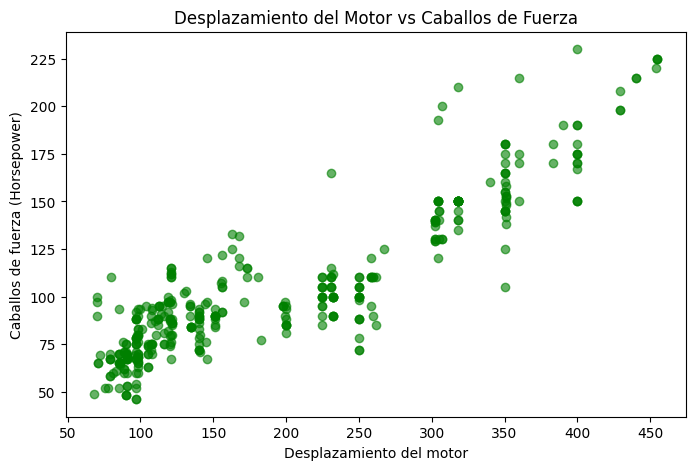

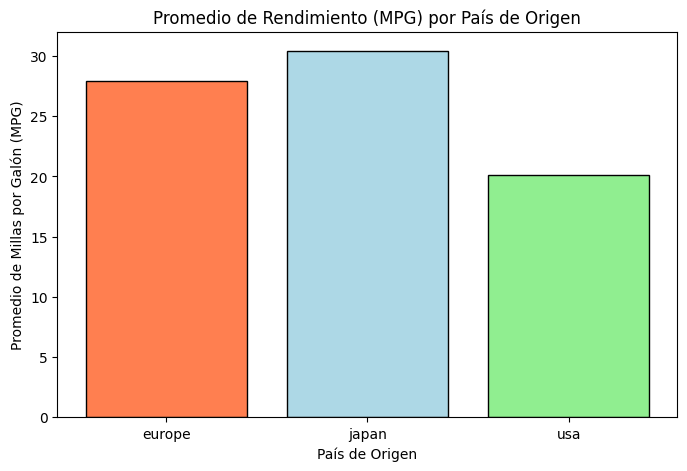

In [ ]:
# Histograma: Muestra la distribución de la aceleración (acceleration) de los vehículos.
plt.figure(figsize=(8, 5))
plt.hist(df['acceleration'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribución de la Aceleración de los Vehículos')
plt.xlabel('Aceleración')
plt.ylabel('Frecuencia (Cantidad de Autos)')
plt.show()

# Gráfico de Dispersión (Scatter): Grafica el Desplazamiento del motor (displacement) en el eje X versus los Caballos de fuerza (horsepower) en el eje Y.
plt.figure(figsize=(8, 5))
plt.scatter(df['displacement'], df['horsepower'], alpha=0.6, color='green')
plt.title('Desplazamiento del Motor vs Caballos de Fuerza')
plt.xlabel('Desplazamiento del motor')
plt.ylabel('Caballos de fuerza (Horsepower)')
plt.show()

# Gráfico de Barras: Muestra el promedio de rendimiento (mpg - millas por galón) agrupado por el país de origen (origin).
promedio_mpg = df.groupby('origin')['mpg'].mean()

plt.figure(figsize=(8, 5))
plt.bar(promedio_mpg.index, promedio_mpg.values, color=['coral', 'lightblue', 'lightgreen'], edgecolor='black')
plt.title('Promedio de Rendimiento (MPG) por País de Origen')
plt.xlabel('País de Origen')
plt.ylabel('Promedio de Millas por Galón (MPG)')
plt.show()